In [1]:
import sys
import os
import time
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

_root = Path.cwd()
while not (_root / 'scripts' / 'config.py').exists():
    if _root == _root.parent:
        raise RuntimeError("Cannot find project root - launch Jupyter from the project directory")
    _root = _root.parent
os.chdir(_root)
sys.path.insert(0, str(_root / 'scripts'))
print(f"Working directory: {os.getcwd()}")

import config as cfg
cfg.set_population_config("sea_jpt_cn")
PATHS = cfg.PATHS
SITUATIONAL_FILTERS = cfg.SITUATIONAL_FILTERS
POPULATIONS = cfg.POPULATIONS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import subprocess
import pyarrow.parquet as pq

from scipy.stats import f_oneway, chi2 as chi2_dist
from statsmodels.stats.multitest import fdrcorrection
from utils import count_variants

print("All imports successful!")

Working directory: /home/ibmelab/Projects/AISNP-Research
All imports successful!


## Step 1: Load Filtered Data from Step 02

In [2]:
INPUT_PFILE = str(PATHS.PLINK_LD_PRUNED)
SAMPLES_CSV = str(PATHS.EAS_SAMPLES_CSV)
OUTPUT_DIR = str(PATHS.OUTPUT_DIR)

print(f"Input pfile: {INPUT_PFILE}")
print(f"Samples CSV: {SAMPLES_CSV}")

n_variants = count_variants(INPUT_PFILE)
print(f"Variants after LD pruning: {n_variants}")

samples_df = pd.read_csv(SAMPLES_CSV, header=None)
samples_df.columns = ["sample", "pop", "super_pop"]
print(f"\nSamples: {len(samples_df)}")
print(f"Populations: {samples_df['pop'].unique()}")
print(f"\nPopulation distribution:")
print(samples_df['pop'].value_counts())

Input pfile: data/1000genomes/output_sea_jpt_cn/SEA_JPT_CN_FINAL_DATA_FOR_FST
Samples CSV: data/1000genomes/SEA_JPT_CN_subpopulation_samples.csv
Variants after LD pruning: 614759

Samples: 504
Populations: ['CN' 'SEA' 'JPT']

Population distribution:
pop
CN     208
SEA    192
JPT    104
Name: count, dtype: int64


## Step 2: Build Genotype Matrix

Parquet cache avoids re-parsing the VCF on subsequent runs.

In [3]:
vcf_output   = str(PATHS.OUTPUT_DIR / "statistical_analysis_temp")
parquet_cache = str(PATHS.OUTPUT_DIR / "genotype_matrix_rc1_cache.parquet")
numpy_cache   = str(PATHS.OUTPUT_DIR / "genotype_matrix_rc2_cache.npz")
cols_cache    = str(PATHS.OUTPUT_DIR / "genotype_matrix_rc2_cols.txt")

gt_map = {
    '0/0': 0, '0|0': 0,
    '0/1': 1, '1/0': 1, '0|1': 1, '1|0': 1,
    '1/1': 2, '1|1': 2,
}

def vcf_to_genotype_matrix(vcf_path):
    genotypes = {}
    sample_names = []
    with open(vcf_path) as f:
        for line in tqdm(f, desc="Parsing VCF"):
            if line.startswith('##'):
                continue
            if line.startswith('#CHROM'):
                sample_names = line.strip().split('\t')[9:]
                continue
            fields = line.strip().split('\t')
            snp_id = fields[2] if fields[2] != '.' else f"{fields[0]}:{fields[1]}"
            genotypes[snp_id] = [gt_map.get(g.split(':')[0], -1) for g in fields[9:]]
    return pd.DataFrame(genotypes, index=sample_names)

# ── Load strategy: numpy cache → parquet (raised limits) → rebuild VCF ───────
if os.path.exists(numpy_cache) and os.path.exists(cols_cache):
    print("Loading numpy cache (fast path)...")
    t0 = time.time()
    data = np.load(numpy_cache)
    G_np = data['G']                              # (n_samples, n_snps)
    _sample_names = list(data['samples'].astype(str))
    with open(cols_cache) as f:
        _snp_ids = [l.strip() for l in f]
    # Reconstruct DataFrame shape expected by downstream cells
    genotype_df = pd.DataFrame(G_np, index=_sample_names, columns=_snp_ids).astype(np.int8)
    mem_mb = G_np.nbytes / 1e6
    print(f"Loaded in {time.time()-t0:.1f}s: {genotype_df.shape}, {mem_mb:.0f} MB")

elif os.path.exists(parquet_cache):
    print("Loading parquet cache with raised thrift limits...")
    try:
        t0 = time.time()
        table = pq.read_table(
            parquet_cache,
            thrift_string_size_limit=1_000_000_000,
            thrift_container_size_limit=1_000_000_000,
        )
        genotype_df = table.to_pandas().astype(np.int8)
        mem_mb = genotype_df.memory_usage(deep=True).sum() / 1e6
        print(f"Loaded in {time.time()-t0:.1f}s: {genotype_df.shape}, {mem_mb:.0f} MB")
        # Save numpy cache so future runs skip parquet entirely
        print("Saving numpy cache for future runs...")
        np.savez_compressed(
            numpy_cache,
            G=genotype_df.values,
            samples=np.array(list(genotype_df.index), dtype=str),
        )
        with open(cols_cache, 'w') as f:
            f.write('\n'.join(genotype_df.columns))
        print("Numpy cache saved.")
    except Exception as e:
        print(f"Parquet failed: {e}\nRebuilding from VCF...")
        cmd = f"plink2 --pfile {INPUT_PFILE} --export vcf --out {vcf_output}"
        result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
        if result.returncode != 0:
            raise RuntimeError(f"plink2 failed: {result.stderr}")
        genotype_df = vcf_to_genotype_matrix(f"{vcf_output}.vcf").astype(np.int8)
        mem_mb = genotype_df.memory_usage(deep=True).sum() / 1e6
        print(f"Matrix: {genotype_df.shape}, {mem_mb:.0f} MB")
        print("Saving parquet cache...")
        genotype_df.to_parquet(parquet_cache)
        print("Saving numpy cache...")
        np.savez_compressed(
            numpy_cache,
            G=genotype_df.values,
            samples=np.array(list(genotype_df.index), dtype=str),
        )
        with open(cols_cache, 'w') as f:
            f.write('\n'.join(genotype_df.columns))
        print("Caches saved.")
        for f_path in [f"{vcf_output}.vcf", f"{vcf_output}.log"]:
            if os.path.exists(f_path):
                os.remove(f_path)

else:
    print("No cache found. Exporting pfile to VCF...")
    cmd = f"plink2 --pfile {INPUT_PFILE} --export vcf --out {vcf_output}"
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(f"plink2 failed: {result.stderr}")
    genotype_df = vcf_to_genotype_matrix(f"{vcf_output}.vcf").astype(np.int8)
    mem_mb = genotype_df.memory_usage(deep=True).sum() / 1e6
    print(f"Matrix: {genotype_df.shape}, {mem_mb:.0f} MB")
    print("Saving parquet cache...")
    genotype_df.to_parquet(parquet_cache)
    print("Saving numpy cache...")
    np.savez_compressed(
        numpy_cache,
        G=genotype_df.values,
        samples=np.array(list(genotype_df.index), dtype=str),
    )
    with open(cols_cache, 'w') as f:
        f.write('\n'.join(genotype_df.columns))
    print("Caches saved.")
    for f_path in [f"{vcf_output}.vcf", f"{vcf_output}.log"]:
        if os.path.exists(f_path):
            os.remove(f_path)

Loading parquet cache with raised thrift limits...
Loaded in 64.8s: (504, 614759), 310 MB
Saving numpy cache for future runs...
Numpy cache saved.


In [4]:
# Add population labels
if 'pop' not in genotype_df.columns:
    genotype_df = genotype_df.reset_index().rename(columns={'index': 'sample'})
    genotype_df = genotype_df.merge(samples_df[['sample', 'pop']], on='sample', how='left')
    cols = ['sample', 'pop'] + [c for c in genotype_df.columns if c not in ['sample', 'pop']]
    genotype_df = genotype_df[cols]

print(f"Dataset with labels: {genotype_df.shape}")
print(f"\nPopulation distribution:")
print(genotype_df['pop'].value_counts())

Dataset with labels: (504, 614761)

Population distribution:
pop
CN     208
SEA    192
JPT    104
Name: count, dtype: int64


## Step 3: Vectorized Batch Analysis

**RC1 approach:** build a shared `pop_geno_counts` tensor (n_pops × 3 × n_snps) once,
then derive all test statistics from it using numpy matrix ops — no Python loop over SNPs.

Tests (all independent, saved separately — no merging):
1. Chi-squared  
2. Cramér's V (effect size; free from chi2)
3. ANOVA F-statistic  
4. Kruskal-Wallis H (vectorized for discrete {0,1,2} genotypes, with tie correction)  
5. Allele Frequency Max Delta  
6. Jensen-Shannon Divergence  
7. Mutual Information  

In [5]:
snp_columns = [c for c in genotype_df.columns if c not in ['sample', 'pop']]
populations = genotype_df['pop']
pop_names = sorted(populations.unique())
n_pops = len(pop_names)

print(f"SNPs to analyze: {len(snp_columns):,}")
print(f"Populations: {pop_names}")

# SNP columns are already int8 from the parquet cache — .values gives int8 directly
G = genotype_df[snp_columns].values  # (n_samples, n_snps), int8
n_total, n_snps = G.shape

pop_masks = [populations.values == p for p in pop_names]
n_sizes = np.array([mask.sum() for mask in pop_masks], dtype=np.float32)  # (n_pops,)

print(f"\nGenotype matrix: {G.shape}, dtype={G.dtype}, {G.nbytes / 1e6:.0f} MB")
print(f"Pop sizes: {dict(zip(pop_names, n_sizes.astype(int)))}")

# ── Core shared tensor ──────────────────────────────────────────────────────
# pop_geno_counts[i, v, j] = count of genotype v in population i for SNP j
# Shape: (n_pops, 3, n_snps)  |  ~13 MB for this dataset
print("\nBuilding per-population genotype count tensor...")
t0 = time.time()
pop_geno_counts = np.zeros((n_pops, 3, n_snps), dtype=np.float32)
for i, mask in enumerate(pop_masks):
    G_pop = G[mask]  # (n_i, n_snps)
    for v in range(3):
        pop_geno_counts[i, v] = (G_pop == v).sum(axis=0)

geno_counts = pop_geno_counts.sum(axis=0)  # (3, n_snps) — global counts per genotype value
print(f"Done in {time.time()-t0:.1f}s  |  tensor shape: {pop_geno_counts.shape}")

SNPs to analyze: 614,759
Populations: ['CN', 'JPT', 'SEA']

Genotype matrix: (504, 614759), dtype=int8, 310 MB
Pop sizes: {'CN': np.int64(208), 'JPT': np.int64(104), 'SEA': np.int64(192)}

Building per-population genotype count tensor...
Done in 3.9s  |  tensor shape: (3, 3, 614759)


In [6]:
# ── 1. Chi-squared + 2. Cramér's V ─────────────────────────────────────────
t0 = time.time()

# Expected counts under independence
row_sums = pop_geno_counts.sum(axis=1)          # (n_pops, n_snps)  — = n_sizes[:,None]
col_sums = geno_counts                           # (3, n_snps)
expected = (row_sums[:, np.newaxis, :] * col_sums[np.newaxis, :, :]) / n_total  # (n_pops, 3, n_snps)

# Zero expected → skip cell (safe_expected = inf → contributes 0 to chi2)
safe_expected = np.where(expected > 0.5, expected, np.inf)
chi2_stat = ((pop_geno_counts - expected) ** 2 / safe_expected).sum(axis=(0, 1))  # (n_snps,)
chi2_df = (n_pops - 1) * (3 - 1)   # 4 for 3-pop × 3-genotype
chi2_pval = chi2_dist.sf(chi2_stat, df=chi2_df)

# Cramér's V: effect size in [0, 1]; comparable across SNPs regardless of n
cramers_v = np.sqrt(chi2_stat / (n_total * min(n_pops - 1, 2)))

print(f"Chi-squared + Cramér's V:  {time.time()-t0:.1f}s")
print(f"  chi2 — median: {np.nanmedian(chi2_stat):.2f}, max: {np.nanmax(chi2_stat):.2f}")
print(f"  V    — median: {np.nanmedian(cramers_v):.4f}, max: {np.nanmax(cramers_v):.4f}")

Chi-squared + Cramér's V:  0.1s
  chi2 — median: 3.27, max: 175.08
  V    — median: 0.0570, max: 0.4168


In [7]:
# ── 3. ANOVA F-statistic ────────────────────────────────────────────────────
# Treats dosage (0/1/2) as a continuous value; tests whether population means differ.
# f_oneway with 2D group arrays computes per-column (per-SNP) statistics.
t0 = time.time()

groups = [G[mask].astype(np.float32) for mask in pop_masks]  # list of (n_i, n_snps)
F_stat, anova_pval = f_oneway(*groups)

print(f"ANOVA F-statistic:  {time.time()-t0:.1f}s")
print(f"  F — median: {np.nanmedian(F_stat):.2f}, max: {np.nanmax(F_stat):.2f}")

ANOVA F-statistic:  11.1s
  F — median: 1.57, max: 133.34


In [8]:
# ── 4. Kruskal-Wallis H (vectorized, exact midrank for {0,1,2} genotypes) ──
# Non-parametric one-way ANOVA on dosage ranks.
# For discrete genotype values the midrank formula is exact and fully vectorizable.
t0 = time.time()

# Midrank for each genotype value across all samples (per SNP)
mr = np.zeros((3, n_snps), dtype=np.float32)
mr[0] = (1 + geno_counts[0]) / 2
mr[1] = geno_counts[0] + (1 + geno_counts[1]) / 2
mr[2] = geno_counts[0] + geno_counts[1] + (1 + geno_counts[2]) / 2

# T_i = sum of ranks for population i  →  (n_pops, n_snps)
T = (pop_geno_counts * mr[np.newaxis, :, :]).sum(axis=1)

# H statistic (before tie correction)
H_stat = (
    (12 / (n_total * (n_total + 1))) * (T ** 2 / n_sizes[:, np.newaxis]).sum(axis=0)
    - 3 * (n_total + 1)
)

# Tie correction: C = 1 - Σ(t_j^3 - t_j) / (N^3 - N)
tied_sum = (geno_counts ** 3 - geno_counts).sum(axis=0)  # (n_snps,)
tie_correction = 1.0 - tied_sum / (n_total ** 3 - n_total)
H_stat = np.where(tie_correction > 0, H_stat / tie_correction, 0.0)
H_stat = np.maximum(H_stat, 0)  # numerical stability
kw_pval = chi2_dist.sf(H_stat, df=n_pops - 1)  # df = 2

print(f"Kruskal-Wallis H:  {time.time()-t0:.1f}s")
print(f"  H — median: {np.nanmedian(H_stat):.2f}, max: {np.nanmax(H_stat):.2f}")

Kruskal-Wallis H:  0.1s
  H — median: 3.13, max: 174.73


In [9]:
# ── 5. Allele Frequency Max Delta ───────────────────────────────────────────
# Max pairwise |AF_i - AF_j| across all population pairs.
# Directly measures what FST estimates — intuitive and interpretable.
t0 = time.time()

# AF per population: (count_het + 2*count_homalt) / (2 * n_i)
af = (
    (pop_geno_counts[:, 1, :] + 2 * pop_geno_counts[:, 2, :])
    / (2 * n_sizes[:, np.newaxis] + 1e-10)
)  # (n_pops, n_snps)

max_af_delta = np.zeros(n_snps, dtype=np.float32)
for i in range(n_pops):
    for j in range(i + 1, n_pops):
        max_af_delta = np.maximum(max_af_delta, np.abs(af[i] - af[j]))

print(f"Allele Frequency Max Delta:  {time.time()-t0:.1f}s")
print(f"  delta — median: {np.median(max_af_delta):.4f}, max: {np.max(max_af_delta):.4f}")

Allele Frequency Max Delta:  0.0s
  delta — median: 0.0130, max: 0.4886


In [10]:
# ── 6. Jensen-Shannon Divergence ────────────────────────────────────────────
# Symmetric, bounded [0, ln2] alternative to KL divergence.
# JSD = mean KL(P_i || M) where M = uniform mixture of population distributions.
# More numerically stable than asymmetric KL — no blow-up on near-zero probs.
t0 = time.time()

# P(geno=v | pop=i, SNP=j)  —  add small epsilon then renormalize
pop_geno_freq = (pop_geno_counts + 1e-10) / (n_sizes[:, np.newaxis, np.newaxis] + 3e-10)  # (n_pops, 3, n_snps)

M = pop_geno_freq.mean(axis=0)  # mixture distribution  (3, n_snps)

# KL(P_i || M) per population per SNP  →  (n_pops, n_snps)
kl_from_M = (pop_geno_freq * np.log(pop_geno_freq / (M[np.newaxis, :, :] + 1e-10))).sum(axis=1)
jsd = np.maximum(kl_from_M.mean(axis=0), 0)  # (n_snps,)

print(f"Jensen-Shannon Divergence:  {time.time()-t0:.1f}s")
print(f"  JSD — median: {np.nanmedian(jsd):.4f}, max: {np.nanmax(jsd):.4f}")

Jensen-Shannon Divergence:  0.1s
  JSD — median: 0.0045, max: 0.1953


In [11]:
# ── 7. Mutual Information (vectorized via entropy decomposition) ─────────────
# MI(G; P) = H(G) + H(P) - H(G, P)
# Matches sklearn.metrics.mutual_info_score but runs in seconds on 600k SNPs.
t0 = time.time()

joint_prob = pop_geno_counts / n_total                         # (n_pops, 3, n_snps)
geno_marginal = geno_counts / n_total                          # (3, n_snps)
pop_marginal = n_sizes / n_total                               # (n_pops,)

# Use masked log to avoid log(0)
def safe_entropy(p, axis):
    log_p = np.where(p > 0, np.log(p + 1e-300), 0.0)
    return -(p * log_p).sum(axis=axis)

H_pop = safe_entropy(pop_marginal, axis=0)                     # scalar
H_geno = safe_entropy(geno_marginal, axis=0)                   # (n_snps,)
H_joint = safe_entropy(joint_prob, axis=(0, 1))                # (n_snps,)

mi_score = np.maximum(H_geno + H_pop - H_joint, 0)            # (n_snps,)

print(f"Mutual Information:  {time.time()-t0:.1f}s")
print(f"  MI — median: {np.nanmedian(mi_score):.4f}, max: {np.nanmax(mi_score):.4f}")

Mutual Information:  0.1s
  MI — median: 0.0040, max: 0.1922


In [12]:
# Assemble full results DataFrame
results_df = pd.DataFrame({
    'snp_id':            snp_columns,
    'chi2_stat':         chi2_stat,
    'chi2_pvalue':       chi2_pval,
    'cramers_v':         cramers_v,
    'anova_F':           F_stat,
    'anova_pvalue':      anova_pval,
    'kw_H':              H_stat,
    'kw_pvalue':         kw_pval,
    'af_max_delta':      max_af_delta,
    'jsd':               jsd,
    'mutual_information': mi_score,
})

print(f"Results shape: {results_df.shape}")
display(results_df.describe())

Results shape: (614759, 11)


,chi2_stat,chi2_pvalue,cramers_v,anova_F,anova_pvalue,kw_H,kw_pvalue,af_max_delta,jsd,mutual_information
count,614759.000000,6.147590e+05,614759.000000,614759.000000,6.147590e+05,614759.000000,6.147590e+05,614759.000000,614759.000000,6.147590e+05
mean,5.148414,5.055976e-01,0.062019,2.528971,2.966553e-01,4.945018,2.966337e-01,0.023339,0.006437,5.705163e-03
std,6.251956,3.457997e-01,0.035513,3.249311,2.780154e-01,6.079779,2.777079e-01,0.029681,0.006883,5.950156e-03
min,0.000000,8.483677e-37,0.000000,0.000000,3.731606e-47,0.000000,1.139925e-38,0.000000,0.000000,1.192093e-07
25%,1.426762,1.657771e-01,0.037622,0.710722,4.927665e-02,1.417841,4.982869e-02,0.007212,0.002233,1.849055e-03
50%,3.270911,5.135544e-01,0.056964,1.571819,2.086895e-01,3.131783,2.089017e-01,0.013021,0.004535,4.007339e-03
75%,6.484382,8.395306e-01,0.080205,3.028465,4.917840e-01,5.998329,4.921751e-01,0.026442,0.007994,7.340670e-03
max,175.081940,1.000000e+00,0.416764,133.339322,1.000000e+00,174.734543,1.000000e+00,0.488582,0.195298,1.921573e-01


## Step 4: FDR Correction — Applied Independently Per Test

Each p-value series is corrected in isolation.  
Tests are **not merged** — diminishing returns from requiring all tests to agree outweigh the gain in specificity when signal is already strong.

In [13]:
alpha = 0.05
bonf_alpha = alpha / len(results_df)
print(f"Bonferroni threshold: {bonf_alpha:.2e}  (n_tests={len(results_df):,})\n")

for pval_col, label in [('chi2_pvalue', 'chi2'), ('anova_pvalue', 'anova'), ('kw_pvalue', 'kw')]:
    pvals = results_df[pval_col].fillna(1).values
    reject, qvals = fdrcorrection(pvals, alpha=alpha)
    results_df[f'{label}_qvalue'] = qvals
    results_df[f'{label}_sig_fdr'] = reject
    results_df[f'{label}_sig_bonf'] = results_df[pval_col] < bonf_alpha
    print(f"{label:6s}:  FDR q<0.05 → {reject.sum():6,}   Bonferroni → {(results_df[pval_col] < bonf_alpha).sum():6,}")

Bonferroni threshold: 8.13e-08  (n_tests=614,759)

chi2  :  FDR q<0.05 → 30,810   Bonferroni →  2,737
anova :  FDR q<0.05 → 73,526   Bonferroni →  4,992
kw    :  FDR q<0.05 → 72,586   Bonferroni →  4,691


## Step 5: Save Per-Test Rankings (Independent, No Merging)

Each test produces its own ranked CSV and top-N ID list.  
Downstream notebooks (04b, 04c) can evaluate which test's SNP list performs best in ML.

In [14]:
output_prefix = str(PATHS.OUTPUT_DIR / "02b_rc1")
top_n = SITUATIONAL_FILTERS.FST_TOP_N

# (name, sort_column, sig_col_for_display)
test_configs = [
    ('chi2',    'chi2_stat',          'chi2_sig_fdr'),
    ('cramers', 'cramers_v',           None),
    ('anova',   'anova_F',            'anova_sig_fdr'),
    ('kw',      'kw_H',               'kw_sig_fdr'),
    ('afdelta', 'af_max_delta',        None),
    ('jsd',     'jsd',                 None),
    ('mi',      'mutual_information',  None),
]

for name, sort_col, sig_col in test_configs:
    ranked = results_df.sort_values(sort_col, ascending=False)

    # Full ranked list
    ranked.to_csv(f"{output_prefix}_{name}_ranked.csv", index=False)

    # Top-N IDs for PLINK extraction
    ranked['snp_id'].head(top_n).to_csv(
        f"{output_prefix}_{name}_top{top_n}_ids.txt", index=False, header=False
    )

    sig_str = f",  FDR sig: {results_df[sig_col].sum():,}" if sig_col else ""
    print(f"{name:8s}: saved  →  {output_prefix}_{name}_ranked.csv{sig_str}")

# Combined scores for reference / custom downstream use
combined_path = f"{output_prefix}_all_scores.csv"
results_df.to_csv(combined_path, index=False)
print(f"\nAll-scores table: {combined_path}")
print(f"Top-N per test:   {top_n} SNPs each, saved as *_top{top_n}_ids.txt")

chi2    : saved  →  data/1000genomes/output_sea_jpt_cn/02b_rc1_chi2_ranked.csv,  FDR sig: 30,810
cramers : saved  →  data/1000genomes/output_sea_jpt_cn/02b_rc1_cramers_ranked.csv
anova   : saved  →  data/1000genomes/output_sea_jpt_cn/02b_rc1_anova_ranked.csv,  FDR sig: 73,526
kw      : saved  →  data/1000genomes/output_sea_jpt_cn/02b_rc1_kw_ranked.csv,  FDR sig: 72,586
afdelta : saved  →  data/1000genomes/output_sea_jpt_cn/02b_rc1_afdelta_ranked.csv
jsd     : saved  →  data/1000genomes/output_sea_jpt_cn/02b_rc1_jsd_ranked.csv
mi      : saved  →  data/1000genomes/output_sea_jpt_cn/02b_rc1_mi_ranked.csv

All-scores table: data/1000genomes/output_sea_jpt_cn/02b_rc1_all_scores.csv
Top-N per test:   1000 SNPs each, saved as *_top1000_ids.txt


## Step 6: Visualizations

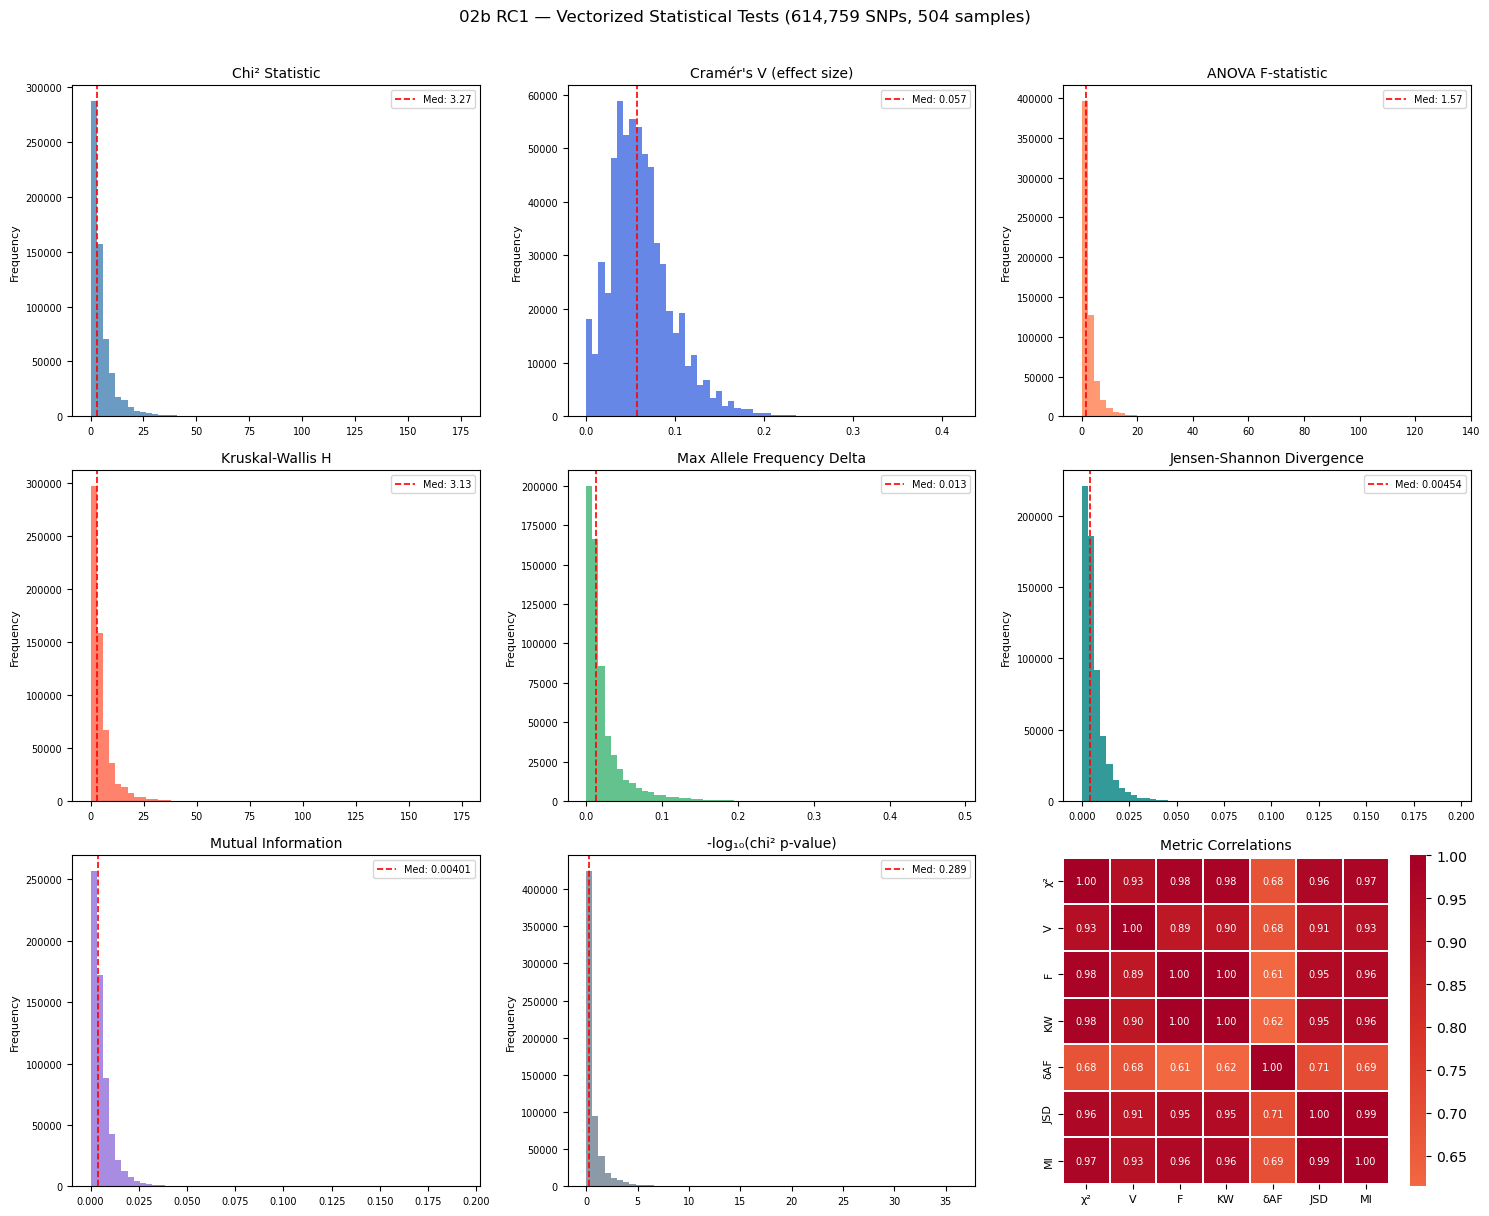

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

dist_configs = [
    ('chi2_stat',          'Chi² Statistic',                'steelblue'),
    ('cramers_v',          "Cramér's V (effect size)",       'royalblue'),
    ('anova_F',            'ANOVA F-statistic',              'coral'),
    ('kw_H',               'Kruskal-Wallis H',               'tomato'),
    ('af_max_delta',       'Max Allele Frequency Delta',     'mediumseagreen'),
    ('jsd',                'Jensen-Shannon Divergence',      'teal'),
    ('mutual_information', 'Mutual Information',             'mediumpurple'),
    ('chi2_pvalue',        '-log₁₀(chi² p-value)',          'slategray'),
]

for ax, (col, label, color) in zip(axes[:8], dist_configs):
    data = results_df[col].dropna()
    if col == 'chi2_pvalue':
        data = -np.log10(data.clip(lower=1e-300))
    ax.hist(data, bins=60, color=color, edgecolor='none', alpha=0.8)
    med = np.nanmedian(data)
    ax.axvline(med, color='red', linewidth=1.2, linestyle='--', label=f'Med: {med:.3g}')
    ax.set_title(label, fontsize=10)
    ax.set_ylabel('Frequency', fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

# Correlation heatmap in final panel
metric_cols = ['chi2_stat', 'cramers_v', 'anova_F', 'kw_H', 'af_max_delta', 'jsd', 'mutual_information']
tick_labels = ['χ²', 'V', 'F', 'KW', 'δAF', 'JSD', 'MI']
corr = results_df[metric_cols].corr()
sns.heatmap(
    corr, ax=axes[8], annot=True, fmt='.2f',
    cmap='RdYlBu_r', center=0, linewidths=0.3, square=True,
    annot_kws={'size': 7},
    xticklabels=tick_labels, yticklabels=tick_labels,
)
axes[8].set_title('Metric Correlations', fontsize=10)
axes[8].tick_params(labelsize=8)

plt.suptitle(
    f'02b RC1 — Vectorized Statistical Tests ({n_snps:,} SNPs, {n_total} samples)',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(f"{output_prefix}_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Top-N overlap across tests (informational — no merging)
check_n = min(500, n_snps)
top_sets = {
    name: set(results_df.nlargest(check_n, sort_col)['snp_id'])
    for name, sort_col, _ in test_configs
}

print(f"Pairwise overlap in top-{check_n} SNPs per test (informational):")
print("="*55)
names = list(top_sets.keys())
for i, n1 in enumerate(names):
    for j, n2 in enumerate(names):
        if i < j:
            overlap = len(top_sets[n1] & top_sets[n2])
            print(f"  {n1:8s} ∩ {n2:8s}: {overlap:4d} ({100*overlap/check_n:.0f}%)")

union_all = set.union(*top_sets.values())
inter_all = set.intersection(*top_sets.values())
print(f"\n  Union  (all {len(names)} tests): {len(union_all):,}")
print(f"  Intersection:              {len(inter_all):,}")
print("\nNote: intersection is shown for reference only — not used for filtering.")

Pairwise overlap in top-500 SNPs per test (informational):
  chi2     ∩ cramers :  500 (100%)
  chi2     ∩ anova   :  473 (95%)
  chi2     ∩ kw      :  463 (93%)
  chi2     ∩ afdelta :   70 (14%)
  chi2     ∩ jsd     :  357 (71%)
  chi2     ∩ mi      :  358 (72%)
  cramers  ∩ anova   :  473 (95%)
  cramers  ∩ kw      :  463 (93%)
  cramers  ∩ afdelta :   70 (14%)
  cramers  ∩ jsd     :  357 (71%)
  cramers  ∩ mi      :  358 (72%)
  anova    ∩ kw      :  472 (94%)
  anova    ∩ afdelta :   55 (11%)
  anova    ∩ jsd     :  342 (68%)
  anova    ∩ mi      :  339 (68%)
  kw       ∩ afdelta :   46 (9%)
  kw       ∩ jsd     :  330 (66%)
  kw       ∩ mi      :  329 (66%)
  afdelta  ∩ jsd     :  138 (28%)
  afdelta  ∩ mi      :  112 (22%)
  jsd      ∩ mi      :  432 (86%)

  Union  (all 7 tests): 1,095
  Intersection:              45

Note: intersection is shown for reference only — not used for filtering.


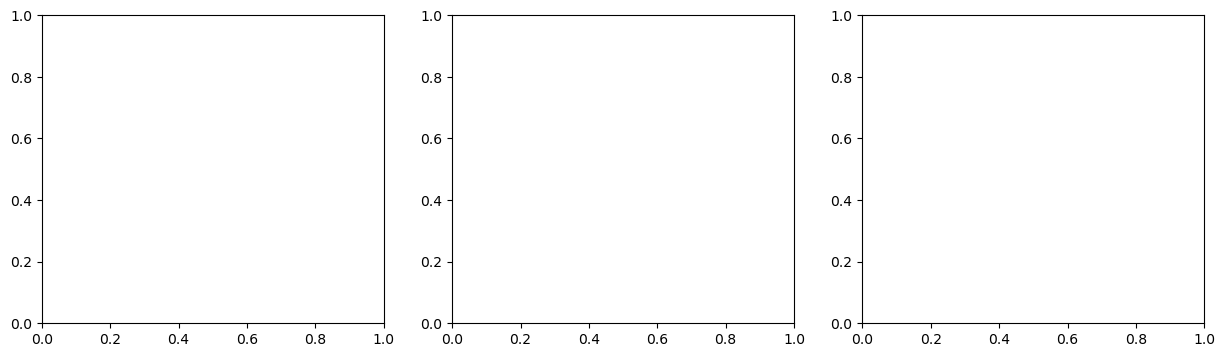

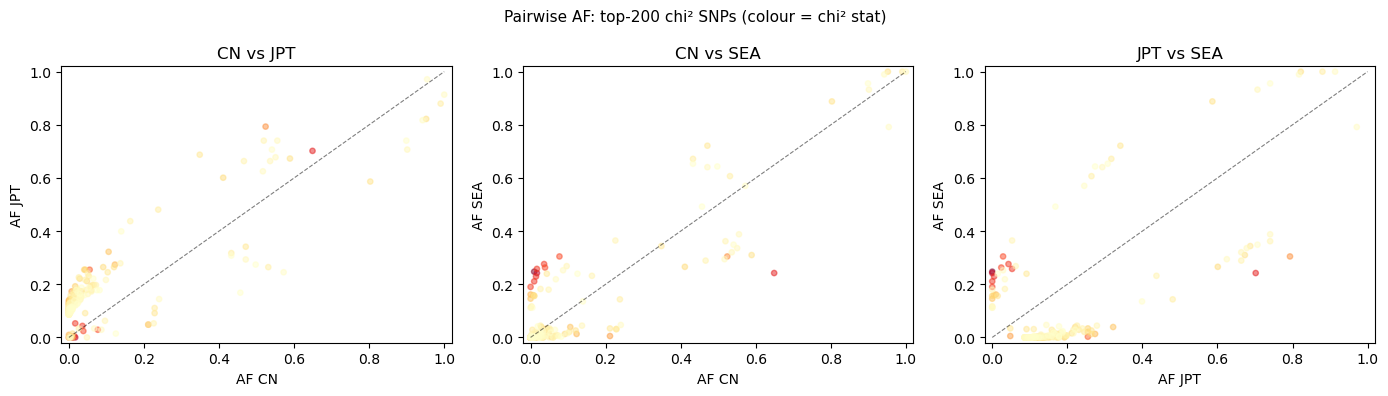

In [17]:
# Per-population allele frequency scatter for top chi2 SNPs
top_snps_plot = results_df.nlargest(200, 'chi2_stat')
idx = top_snps_plot.index
af_top = af[:, idx]  # (n_pops, 200)

fig, axes = plt.subplots(1, n_pops - 1 + (n_pops - 1) * (n_pops - 2) // 2, figsize=(5 * n_pops, 4))
if n_pops == 3:
    pairs = [(0, 1), (0, 2), (1, 2)]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, (i, j) in zip(axes, pairs):
        ax.scatter(af_top[i], af_top[j], alpha=0.5, s=15, c=top_snps_plot['chi2_stat'].values,
                   cmap='YlOrRd')
        ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
        ax.set_xlabel(f'AF {pop_names[i]}')
        ax.set_ylabel(f'AF {pop_names[j]}')
        ax.set_title(f'{pop_names[i]} vs {pop_names[j]}')
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.02)

plt.suptitle('Pairwise AF: top-200 chi² SNPs (colour = chi² stat)', fontsize=11)
plt.tight_layout()
plt.savefig(f"{output_prefix}_af_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

## Summary

In [18]:
print("=" * 70)
print("02b RC1 — VECTORIZED STATISTICAL SNP SELECTION SUMMARY")
print("=" * 70)
print(f"\nInput:  {n_snps:,} SNPs  |  {n_total} samples  |  populations: {pop_names}")
print(f"\nTests run independently (no intersection filtering):")
print(f"  1. Chi-squared       FDR sig: {results_df['chi2_sig_fdr'].sum():,}")
print(f"  2. Cramér's V        (effect size; top {top_n} saved)")
print(f"  3. ANOVA F           FDR sig: {results_df['anova_sig_fdr'].sum():,}")
print(f"  4. Kruskal-Wallis H  FDR sig: {results_df['kw_sig_fdr'].sum():,}")
print(f"  5. Max AF Delta      (top {top_n} saved)")
print(f"  6. Jensen-Shannon D  (top {top_n} saved)")
print(f"  7. Mutual Information(top {top_n} saved)")
print(f"\nOutput files:")
print(f"  {output_prefix}_all_scores.csv  (all 7 metrics per SNP)")
for name, _, _ in test_configs:
    print(f"  {output_prefix}_{name}_ranked.csv")
    print(f"  {output_prefix}_{name}_top{top_n}_ids.txt")
print(f"\nNext:")
print(f"  → 04b/04c: train ML on each test's top-SNP list independently")
print(f"  → 05b:     compare classification accuracy across lists")

02b RC1 — VECTORIZED STATISTICAL SNP SELECTION SUMMARY

Input:  614,759 SNPs  |  504 samples  |  populations: ['CN', 'JPT', 'SEA']

Tests run independently (no intersection filtering):
  1. Chi-squared       FDR sig: 30,810
  2. Cramér's V        (effect size; top 1000 saved)
  3. ANOVA F           FDR sig: 73,526
  4. Kruskal-Wallis H  FDR sig: 72,586
  5. Max AF Delta      (top 1000 saved)
  6. Jensen-Shannon D  (top 1000 saved)
  7. Mutual Information(top 1000 saved)

Output files:
  data/1000genomes/output_sea_jpt_cn/02b_rc1_all_scores.csv  (all 7 metrics per SNP)
  data/1000genomes/output_sea_jpt_cn/02b_rc1_chi2_ranked.csv
  data/1000genomes/output_sea_jpt_cn/02b_rc1_chi2_top1000_ids.txt
  data/1000genomes/output_sea_jpt_cn/02b_rc1_cramers_ranked.csv
  data/1000genomes/output_sea_jpt_cn/02b_rc1_cramers_top1000_ids.txt
  data/1000genomes/output_sea_jpt_cn/02b_rc1_anova_ranked.csv
  data/1000genomes/output_sea_jpt_cn/02b_rc1_anova_top1000_ids.txt
  data/1000genomes/output_sea_jpt_cn